In [1]:
import pandas as pd

df_prc = pd.read_pickle("C:/Users/hp/Downloads/TER_M1_2025/data/ENQUETE_PRC_BC")
print(" Données PRC ")
print("Nombre de lignes :", len(df_prc))
print("Colonnes :", df_prc.columns.tolist())
print(df_prc.head(), "\n")
## ca prend presque 10 mins pour le loading de l'excel vu sa grande taille désolé :/
df_soins = pd.read_excel("C:/Users/hp/Downloads/TER_M1_2025/data/df_all_care_T0_no_filtered.xlsx")
print(" Données de Soins ")
print("Nombre de lignes :", len(df_soins))
print("Colonnes :", df_soins.columns.tolist())
print(df_soins.head())


 Données PRC 
Nombre de lignes : 930
Colonnes : ['ID_PATIENT', 'peur_recidive1']
   ID_PATIENT  peur_recidive1
0  1101100325               2
1  1101100717               3
2  1101100766               1
3  1102100494               2
4  1102101103               3 

 Données de Soins 
Nombre de lignes : 485287
Colonnes : ['ID_PATIENT', 'CODE', 'DAYS_SINCE_DIAG', 'TABLE_ORIGIN', 'Cons_Med_Gen', 'Cons_Spe', 'Mammographie', 'Echo_Mammaire', 'Irm_Mammaire', 'Echo_Abdominal', 'Thorax', 'Scintigraphie_Osseuse', 'Scanner', 'Osteodensitometrie', 'Evaluation_Cardiaque', 'Bilan_Bio', 'Fns', 'Bilan_Hepatique', 'Bilan_Lipidique', 'Ca_15_3', 'Tep_Scan', 'Echo_pelv', 'Echo_endometre', 'Dosage_calcium', 'Dosage_phosphore', 'Dosage_pholphocalcique', 'Cons_gyneco', 'RT', 'HT', 'Tamoxifen', 'Anti_arom', 'GnrH_ago', 'CT', 'Mastectomie', 'Mastectomie_part', 'SURG', 'T0', 'TREATMENT_TYPE']
   ID_PATIENT     CODE  DAYS_SINCE_DIAG TABLE_ORIGIN  Cons_Med_Gen  Cons_Spe  \
0  3104503184  D01AC12                0   

In [2]:
df_prc = pd.read_pickle("C:/Users/hp/Downloads/TER_M1_2025/data/ENQUETE_PRC_BC")
print(" Données PRC ")
print("Nombre de lignes :", len(df_prc))
print("Colonnes :", df_prc.columns.tolist())
print(df_prc.head(), "\n")

 Données PRC 
Nombre de lignes : 930
Colonnes : ['ID_PATIENT', 'peur_recidive1']
   ID_PATIENT  peur_recidive1
0  1101100325               2
1  1101100717               3
2  1101100766               1
3  1102100494               2
4  1102101103               3 



In [3]:
df_soins.to_csv("df_soins.csv", index=False)


In [4]:
df_soins = pd.read_csv("df_soins.csv")
df_soins.columns


Index(['ID_PATIENT', 'CODE', 'DAYS_SINCE_DIAG', 'TABLE_ORIGIN', 'Cons_Med_Gen',
       'Cons_Spe', 'Mammographie', 'Echo_Mammaire', 'Irm_Mammaire',
       'Echo_Abdominal', 'Thorax', 'Scintigraphie_Osseuse', 'Scanner',
       'Osteodensitometrie', 'Evaluation_Cardiaque', 'Bilan_Bio', 'Fns',
       'Bilan_Hepatique', 'Bilan_Lipidique', 'Ca_15_3', 'Tep_Scan',
       'Echo_pelv', 'Echo_endometre', 'Dosage_calcium', 'Dosage_phosphore',
       'Dosage_pholphocalcique', 'Cons_gyneco', 'RT', 'HT', 'Tamoxifen',
       'Anti_arom', 'GnrH_ago', 'CT', 'Mastectomie', 'Mastectomie_part',
       'SURG', 'T0', 'TREATMENT_TYPE'],
      dtype='object')

In [5]:
def recoder_prc(classe):
    if classe in [1, 2]:
        return 0  
    elif classe == 3:
        return 1  
    else:
        return None  

df_prc['PRC'] = df_prc['peur_recidive1'].apply(recoder_prc)

In [6]:
df_prc.head(20)

,ID_PATIENT,peur_recidive1,PRC
0,1101100325,2,0
1,1101100717,3,1
2,1101100766,1,0
3,1102100494,2,0
4,1102101103,3,1
5,1102101659,2,0
6,1102102186,3,1
7,1103100275,1,0
8,1103101510,1,0
9,1103102437,2,0


In [7]:
df_prc = df_prc[['ID_PATIENT', 'PRC']]


In [8]:
df_prc.head(5 )

,ID_PATIENT,PRC
0,1101100325,0
1,1101100717,1
2,1101100766,0
3,1102100494,0
4,1102101103,1


In [9]:
df_merged = df_soins.merge(df_prc, on='ID_PATIENT', how='inner')

In [10]:
df_merged.head(900)

,ID_PATIENT,CODE,DAYS_SINCE_DIAG,TABLE_ORIGIN,Cons_Med_Gen,Cons_Spe,Mammographie,Echo_Mammaire,Irm_Mammaire,Echo_Abdominal,...,Tamoxifen,Anti_arom,GnrH_ago,CT,Mastectomie,Mastectomie_part,SURG,T0,TREATMENT_TYPE,PRC
0,3104503184,D01AC12,0,medic,0,1,0,0,0,0,...,0,0,0,0,0,0,0,161,"CT, HT, RT, SURG",1
1,3104503184,G01AF12,0,medic,0,1,0,0,0,0,...,0,0,0,0,0,0,0,161,"CT, HT, RT, SURG",1
2,3104503184,N07BA01,4,medic,1,0,0,0,0,0,...,0,0,0,0,0,0,0,161,"CT, HT, RT, SURG",1
3,3104503184,C509,13,pmsi,0,0,0,0,0,0,...,0,0,0,0,0,0,0,161,"CT, HT, RT, SURG",1
4,3104503184,FCFA021,13,psmi_act,0,0,0,0,0,0,...,0,0,0,0,0,0,1,161,"CT, HT, RT, SURG",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,4105904747,9105,1351,bio,1,0,0,0,0,0,...,0,0,0,0,0,0,0,102,"SURG, RT, HT",0
896,4105904747,QEQM001,1353,ccam,0,0,0,1,0,0,...,0,0,0,0,0,0,0,102,"SURG, RT, HT",0
897,4105904747,QEQK001,1353,ccam,0,0,1,0,0,0,...,0,0,0,0,0,0,0,102,"SURG, RT, HT",0
898,4105904747,L02BG03,1360,medic,0,1,0,0,0,0,...,0,1,0,0,0,0,0,102,"SURG, RT, HT",0


In [11]:
print("Nombre de patientes uniques :", df_merged['ID_PATIENT'].nunique())


Nombre de patientes uniques : 920


In [12]:
df_post_T0 = df_merged[df_merged["DAYS_SINCE_DIAG"] >= df_merged["T0"]]

In [13]:
df_post_T0

,ID_PATIENT,CODE,DAYS_SINCE_DIAG,TABLE_ORIGIN,Cons_Med_Gen,Cons_Spe,Mammographie,Echo_Mammaire,Irm_Mammaire,Echo_Abdominal,...,Tamoxifen,Anti_arom,GnrH_ago,CT,Mastectomie,Mastectomie_part,SURG,T0,TREATMENT_TYPE,PRC
235,3104503184,9005,168,bio,1,0,0,0,0,0,...,0,0,0,0,0,0,0,161,"CT, HT, RT, SURG",1
236,3104503184,9105,168,bio,1,0,0,0,0,0,...,0,0,0,0,0,0,0,161,"CT, HT, RT, SURG",1
237,3104503184,7321,168,bio,1,0,0,0,0,0,...,0,0,0,0,0,0,0,161,"CT, HT, RT, SURG",1
238,3104503184,2258,168,bio,1,0,0,0,0,0,...,0,0,0,0,0,0,0,161,"CT, HT, RT, SURG",1
239,3104503184,0514,168,bio,1,0,0,0,0,0,...,0,0,0,0,0,0,0,161,"CT, HT, RT, SURG",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
485282,4308300843,L02BG03,888,medic,0,1,0,0,0,0,...,0,1,0,0,0,0,0,804,HT,0
485283,3107502798,L02BG03,1060,medic,1,0,0,0,0,0,...,0,1,0,0,0,0,0,1060,HT,1
485284,3107502798,V08AB10,1106,medic,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1060,HT,1
485285,3107502798,V08BA02,1106,medic,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1060,HT,1


In [14]:
df_post_T0["mois_depuis_T0"] = ((df_post_T0["DAYS_SINCE_DIAG"] - df_post_T0["T0"]) / 30).astype(int)


C:\Users\hp\AppData\Local\Temp\ipykernel_9044\1400350702.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_post_T0["mois_depuis_T0"] = ((df_post_T0["DAYS_SINCE_DIAG"] - df_post_T0["T0"]) / 30).astype(int)


In [15]:
actes_suivi = [
    "Cons_Spe",
    "Mammographie", "Echo_Mammaire", "Irm_Mammaire",
    "Fns", "Ca_15_3",
    "Bilan_Hepatique", "Bilan_Lipidique",
    "Echo_pelv", "Echo_endometre",       
    "Osteodensitometrie",               
    "Dosage_pholphocalcique"            
]

In [16]:
df_suivi_filtré = df_post_T0[df_post_T0[actes_suivi].sum(axis=1) >= 1]


In [17]:
print("Nombre d’actes post-T0 pertinents au suivi :", len(df_suivi_filtré))
print(df_suivi_filtré[["ID_PATIENT", "mois_depuis_T0", "PRC"] + actes_suivi].head())


Nombre d’actes post-T0 pertinents au suivi : 76828
     ID_PATIENT  mois_depuis_T0  PRC  Cons_Spe  Mammographie  Echo_Mammaire  \
237  3104503184               0    1         0             0              0   
239  3104503184               0    1         0             0              0   
240  3104503184               0    1         0             0              0   
241  3104503184               0    1         0             0              0   
243  3104503184               0    1         0             0              0   

     Irm_Mammaire  Fns  Ca_15_3  Bilan_Hepatique  Bilan_Lipidique  Echo_pelv  \
237             0    0        1                0                0          0   
239             0    0        0                1                0          0   
240             0    0        0                1                0          0   
241             0    0        0                1                0          0   
243             0    0        0                0                0         

In [46]:
## de facon régulière 
df_merged["mois_depuis_T0"] = (df_merged["DAYS_SINCE_DIAG"] // 30).astype(int)

def assigner_periode(mois):
    if mois < 0:
        return None
    elif mois < 3:
        return "M0–M3"
    elif mois < 6:
        return "M3–M6"
    elif mois < 9:
        return "M6–M9"
    elif mois < 12:
        return "M9–M12"
    elif mois < 15:
        return "M12–M15"
    elif mois < 18:
        return "M15–M18"
    elif mois < 21:
        return "M18–M21"
    elif mois < 24:
        return "M21–M24"
    elif mois < 27:
        return "M24–M27"
    elif mois < 30:
        return "M27–M30"
    elif mois < 33:
        return "M30–M33"
    elif mois < 36:
        return "M33–M36"
    elif mois < 39:
        return "M36–M39"
    elif mois < 42:
        return "M39–M42"
    elif mois < 45:
        return "M42–M45"
    elif mois < 48:
        return "M45–M48"
    elif mois < 51:
        return "M48–M51"
    elif mois < 54:
        return "M51–M54"
    elif mois < 57:
        return "M54–M57"
    elif mois < 60:
        return "M57–M60"
    else:
        return "M60+"

df_suivi_filtré["periode_suivi"] = df_suivi_filtré["mois_depuis_T0"].apply(assigner_periode)
df_merged['periode_suivi'] = df_merged['mois_depuis_T0'].apply(assigner_periode)
df_resumé_par_periode = df_merged.groupby(["ID_PATIENT", "periode_suivi", "PRC"])[actes_suivi].sum().reset_index()
print(df_resumé_par_periode.head(10))


C:\Users\hp\AppData\Local\Temp\ipykernel_9044\2797617230.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_suivi_filtré["periode_suivi"] = df_suivi_filtré["mois_depuis_T0"].apply(assigner_periode)


   ID_PATIENT periode_suivi  PRC  Cons_Spe  Mammographie  Echo_Mammaire  \
0  1101100325         M0–M3    0        11             1              1   
1  1101100325       M12–M15    0         0             0              0   
2  1101100325       M15–M18    0         0             0              0   
3  1101100325       M18–M21    0         0             0              0   
4  1101100325       M21–M24    0         0             0              0   
5  1101100325       M24–M27    0         0             1              0   
6  1101100325       M27–M30    0         0             0              0   
7  1101100325       M30–M33    0         0             0              0   
8  1101100325       M33–M36    0         1             0              0   
9  1101100325       M36–M39    0         0             1              1   

   Irm_Mammaire  Fns  Ca_15_3  Bilan_Hepatique  Bilan_Lipidique  Echo_pelv  \
0             1    1        0                4                0          0   
1             0   

In [19]:
df_resumé_par_periode.head(10)

,ID_PATIENT,periode_suivi,PRC,Cons_Spe,Mammographie,Echo_Mammaire,Irm_Mammaire,Fns,Ca_15_3,Bilan_Hepatique,Bilan_Lipidique,Echo_pelv,Echo_endometre,Osteodensitometrie,Dosage_pholphocalcique
0,1101100325,M0–M3,0,11,1,1,1,1,0,4,0,0,0,0,1
1,1101100325,M12–M15,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1101100325,M15–M18,0,0,0,0,0,0,0,0,0,0,1,0,0
3,1101100325,M18–M21,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1101100325,M21–M24,0,0,0,0,0,0,0,0,1,0,0,0,1
5,1101100325,M24–M27,0,0,1,0,0,0,0,0,0,0,0,0,0
6,1101100325,M27–M30,0,0,0,0,0,1,1,2,1,0,0,0,1
7,1101100325,M30–M33,0,0,0,0,0,0,0,0,0,0,0,0,0
8,1101100325,M33–M36,0,1,0,0,0,0,0,0,0,0,0,0,0
9,1101100325,M36–M39,0,0,1,1,0,0,0,0,0,0,1,0,0


In [20]:
df_post_T0.to_csv("C:/Users/hp/Downloads/df_post_T0.csv", index=False)
df_suivi_filtré.to_csv("C:/Users/hp/Downloads/df_suivi_filtré.csv", index=False)


In [21]:
df_post_T0.columns

Index(['ID_PATIENT', 'CODE', 'DAYS_SINCE_DIAG', 'TABLE_ORIGIN', 'Cons_Med_Gen',
       'Cons_Spe', 'Mammographie', 'Echo_Mammaire', 'Irm_Mammaire',
       'Echo_Abdominal', 'Thorax', 'Scintigraphie_Osseuse', 'Scanner',
       'Osteodensitometrie', 'Evaluation_Cardiaque', 'Bilan_Bio', 'Fns',
       'Bilan_Hepatique', 'Bilan_Lipidique', 'Ca_15_3', 'Tep_Scan',
       'Echo_pelv', 'Echo_endometre', 'Dosage_calcium', 'Dosage_phosphore',
       'Dosage_pholphocalcique', 'Cons_gyneco', 'RT', 'HT', 'Tamoxifen',
       'Anti_arom', 'GnrH_ago', 'CT', 'Mastectomie', 'Mastectomie_part',
       'SURG', 'T0', 'TREATMENT_TYPE', 'PRC', 'mois_depuis_T0'],
      dtype='object')

NameError: name 'plt' is not defined

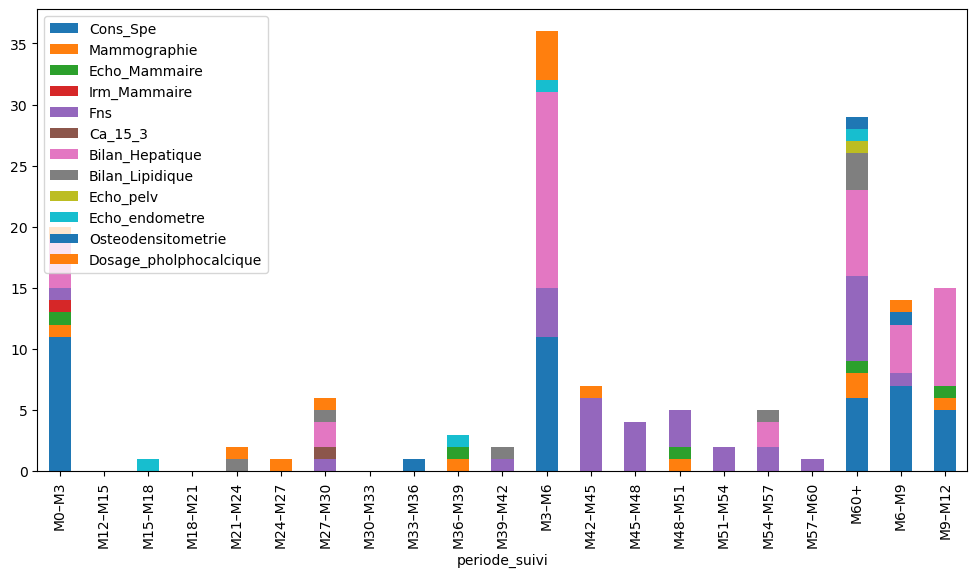

In [22]:

id_exemple = df_resumé_par_periode["ID_PATIENT"].iloc[0]
df_patient = df_resumé_par_periode[df_resumé_par_periode["ID_PATIENT"] == id_exemple]

df_patient.set_index("periode_suivi")[actes_suivi].plot(kind="bar", stacked=True, figsize=(12,6))
plt.title(f"Timeline des actes de suivi – Patiente {id_exemple}")
plt.ylabel("Nombre d'actes")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [25]:
df_vecteurs = df_resumé_par_periode.copy()
df_vecteurs[actes_suivi] = (df_vecteurs[actes_suivi] > 0).astype(int)


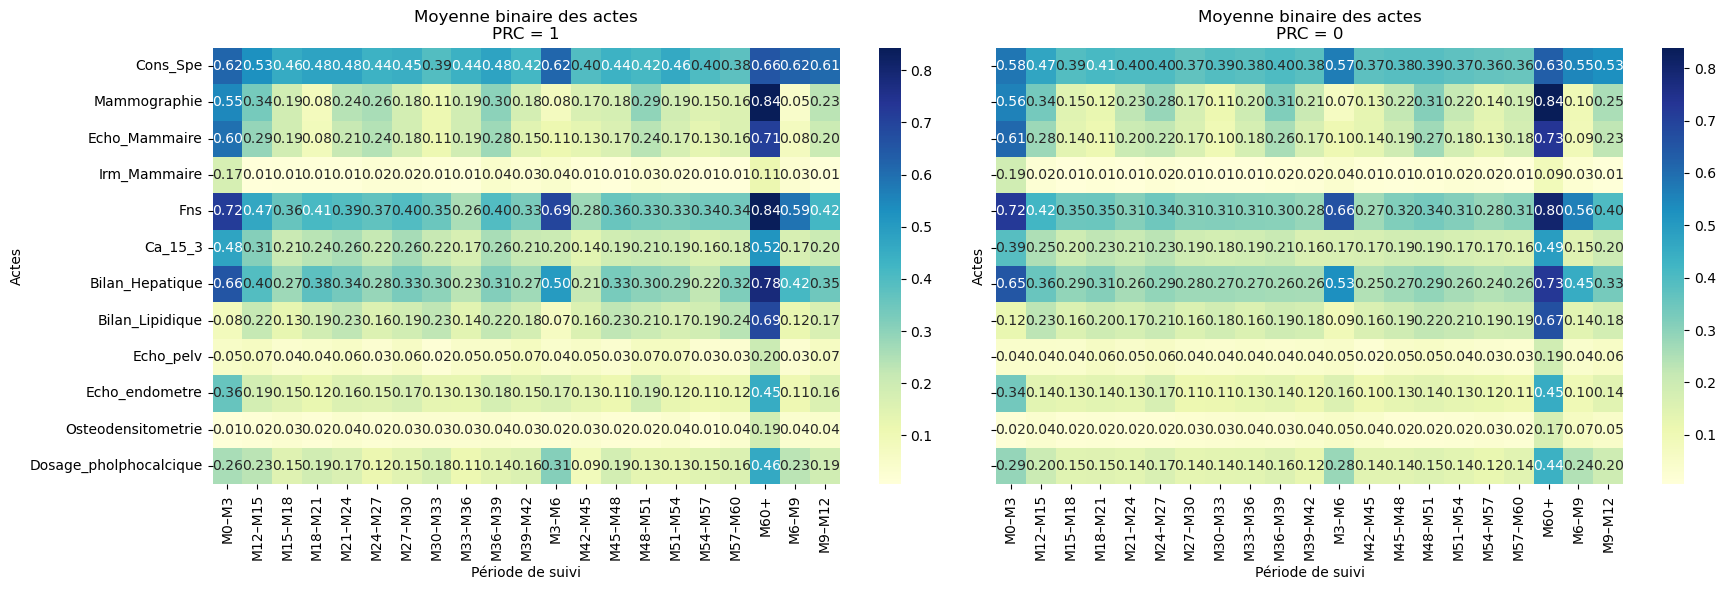

In [29]:
##A diviser entre prc=0 et prc=1
import matplotlib.pyplot as plt

import seaborn as sns

df_heatmap = df_vecteurs.groupby(["periode_suivi", "PRC"])[actes_suivi].mean().T

ig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

for prc_value, ax in zip([1, 0], axes):     # d’abord PRC=1 puis PRC=0
    # Sélectionne les colonnes dont le niveau 'PRC' vaut prc_value
    data = df_heatmap.xs(prc_value, level='PRC', axis=1)

    sns.heatmap(data,
                annot=True,
                cmap="YlGnBu",
                fmt=".2f",
                ax=ax)

    ax.set_title(f"Moyenne binaire des actes\nPRC = {prc_value}")
    ax.set_xlabel("Période de suivi")
    ax.set_ylabel("Actes")

plt.tight_layout()
plt.show()

Les premières analyses descriptives (moyennes, heatmaps) montrent que les femmes avec PRC=1 présentent un suivi plus fréquent que celles avec PRC=0, en particulier au niveau des consultations médicales et bilans biologiques, dès les premiers mois post-traitement.

<AxesSubplot:>

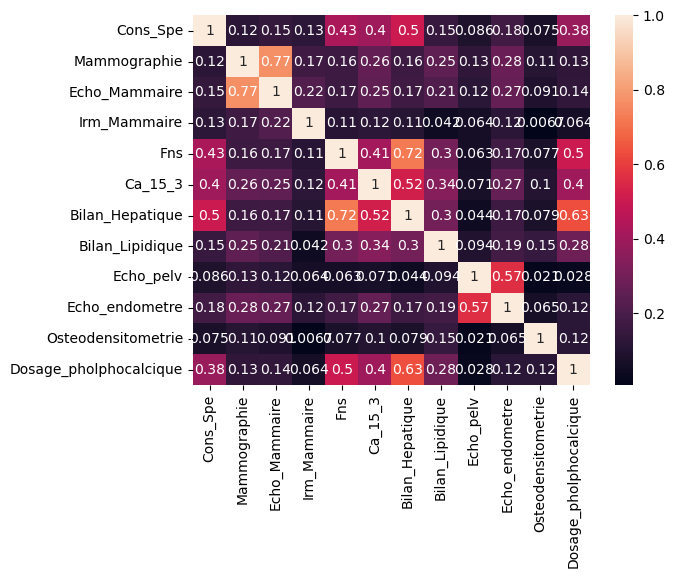

In [30]:
corr = df_resumé_par_periode[actes_suivi].corr()
sns.heatmap(corr, annot=True)


In [31]:
df_var = df_resumé_par_periode.groupby("ID_PATIENT")[actes_suivi].std()


In [32]:
df_resumé_par_periode.head(20)

,ID_PATIENT,periode_suivi,PRC,Cons_Spe,Mammographie,Echo_Mammaire,Irm_Mammaire,Fns,Ca_15_3,Bilan_Hepatique,Bilan_Lipidique,Echo_pelv,Echo_endometre,Osteodensitometrie,Dosage_pholphocalcique
0,1101100325,M0–M3,0,11,1,1,1,1,0,4,0,0,0,0,1
1,1101100325,M12–M15,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1101100325,M15–M18,0,0,0,0,0,0,0,0,0,0,1,0,0
3,1101100325,M18–M21,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1101100325,M21–M24,0,0,0,0,0,0,0,0,1,0,0,0,1
5,1101100325,M24–M27,0,0,1,0,0,0,0,0,0,0,0,0,0
6,1101100325,M27–M30,0,0,0,0,0,1,1,2,1,0,0,0,1
7,1101100325,M30–M33,0,0,0,0,0,0,0,0,0,0,0,0,0
8,1101100325,M33–M36,0,1,0,0,0,0,0,0,0,0,0,0,0
9,1101100325,M36–M39,0,0,1,1,0,0,0,0,0,0,1,0,0


## Etude de Conformité avec les recommendations du PSP

In [47]:
for acte in actes_suivi:
    if acte in df_resumé_par_periode.columns:
        df_resumé_par_periode[f"conf_{acte}"] = (df_resumé_par_periode[acte] >= 1).astype(int)

In [48]:
df_resumé_par_periode.head(20)

,ID_PATIENT,periode_suivi,PRC,Cons_Spe,Mammographie,Echo_Mammaire,Irm_Mammaire,Fns,Ca_15_3,Bilan_Hepatique,...,conf_Echo_Mammaire,conf_Irm_Mammaire,conf_Fns,conf_Ca_15_3,conf_Bilan_Hepatique,conf_Bilan_Lipidique,conf_Echo_pelv,conf_Echo_endometre,conf_Osteodensitometrie,conf_Dosage_pholphocalcique
0,1101100325,M0–M3,0,11,1,1,1,1,0,4,...,1,1,1,0,1,0,0,0,0,1
1,1101100325,M12–M15,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1101100325,M15–M18,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,1101100325,M18–M21,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1101100325,M21–M24,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
5,1101100325,M24–M27,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,1101100325,M27–M30,0,0,0,0,0,1,1,2,...,0,0,1,1,1,1,0,0,0,1
7,1101100325,M30–M33,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,1101100325,M33–M36,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,1101100325,M36–M39,0,0,1,1,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0


In [36]:
df_resumé_par_periode.head(20)

,ID_PATIENT,periode_suivi,PRC,Cons_Spe,Mammographie,Echo_Mammaire,Irm_Mammaire,Fns,Ca_15_3,Bilan_Hepatique,...,conf_Echo_Mammaire,conf_Irm_Mammaire,conf_Fns,conf_Ca_15_3,conf_Bilan_Hepatique,conf_Bilan_Lipidique,conf_Echo_pelv,conf_Echo_endometre,conf_Osteodensitometrie,conf_Dosage_pholphocalcique
0,1101100325,M0–M3,0,11,1,1,1,1,0,4,...,1,1,1,0,1,0,0,0,0,1
1,1101100325,M12–M15,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1101100325,M15–M18,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,1101100325,M18–M21,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1101100325,M21–M24,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
5,1101100325,M24–M27,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,1101100325,M27–M30,0,0,0,0,0,1,1,2,...,0,0,1,1,1,1,0,0,0,1
7,1101100325,M30–M33,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,1101100325,M33–M36,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,1101100325,M36–M39,0,0,1,1,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0


In [49]:
import re

def extraire_mois_milieu(periode):
    match = re.findall(r"M(\d+)", periode)
    if match:
        mois_debut = int(match[0])
        mois_fin = int(match[-1])
        return (mois_debut + mois_fin) // 2
    return None

df_resumé_par_periode["mois_suivi"] = df_resumé_par_periode["periode_suivi"].apply(extraire_mois_milieu)


In [50]:
def conforme_annuel(df_patient, acte, nb_annees=5):
    for annee in range(nb_annees):
        min_mois = annee * 12
        max_mois = min_mois + 12
        # Fait au moins une fois dans l’année ?
        done = df_patient[
            (df_patient["mois_suivi"] >= min_mois) & (df_patient["mois_suivi"] < max_mois)
        ][acte].fillna(0).ge(1).any()
        if not done:
            return 0
    return 1
def conforme_a_n_mois(df_patient, acte, mois_cible, tolérance=3):
    """Vérifie si l'acte est fait autour du mois_cible (+/- tolérance)"""
    min_mois = mois_cible - tolérance
    max_mois = mois_cible + tolérance
    return int(
        df_patient[
            (df_patient["mois_suivi"] >= min_mois) & (df_patient["mois_suivi"] <= max_mois)
        ][acte].fillna(0).ge(1).any()
    )


In [39]:
print(df_resumé_par_periode.columns.tolist())


['ID_PATIENT', 'periode_suivi', 'PRC', 'Cons_Spe', 'Mammographie', 'Echo_Mammaire', 'Irm_Mammaire', 'Fns', 'Ca_15_3', 'Bilan_Hepatique', 'Bilan_Lipidique', 'Echo_pelv', 'Echo_endometre', 'Osteodensitometrie', 'Dosage_pholphocalcique', 'conf_Cons_Spe', 'conf_Mammographie', 'conf_Echo_Mammaire', 'conf_Irm_Mammaire', 'conf_Fns', 'conf_Ca_15_3', 'conf_Bilan_Hepatique', 'conf_Bilan_Lipidique', 'conf_Echo_pelv', 'conf_Echo_endometre', 'conf_Osteodensitometrie', 'conf_Dosage_pholphocalcique', 'mois_suivi']


In [40]:
df_patient.columns

Index(['ID_PATIENT', 'periode_suivi', 'PRC', 'Cons_Spe', 'Mammographie',
       'Echo_Mammaire', 'Irm_Mammaire', 'Fns', 'Ca_15_3', 'Bilan_Hepatique',
       'Bilan_Lipidique', 'Echo_pelv', 'Echo_endometre', 'Osteodensitometrie',
       'Dosage_pholphocalcique'],
      dtype='object')

In [51]:
traitements = df_merged.groupby("ID_PATIENT")[["Tamoxifen", "Anti_arom", "CT"]].max().reset_index()
df_resumé_par_periode = df_resumé_par_periode.merge(traitements, on="ID_PATIENT", how="left")

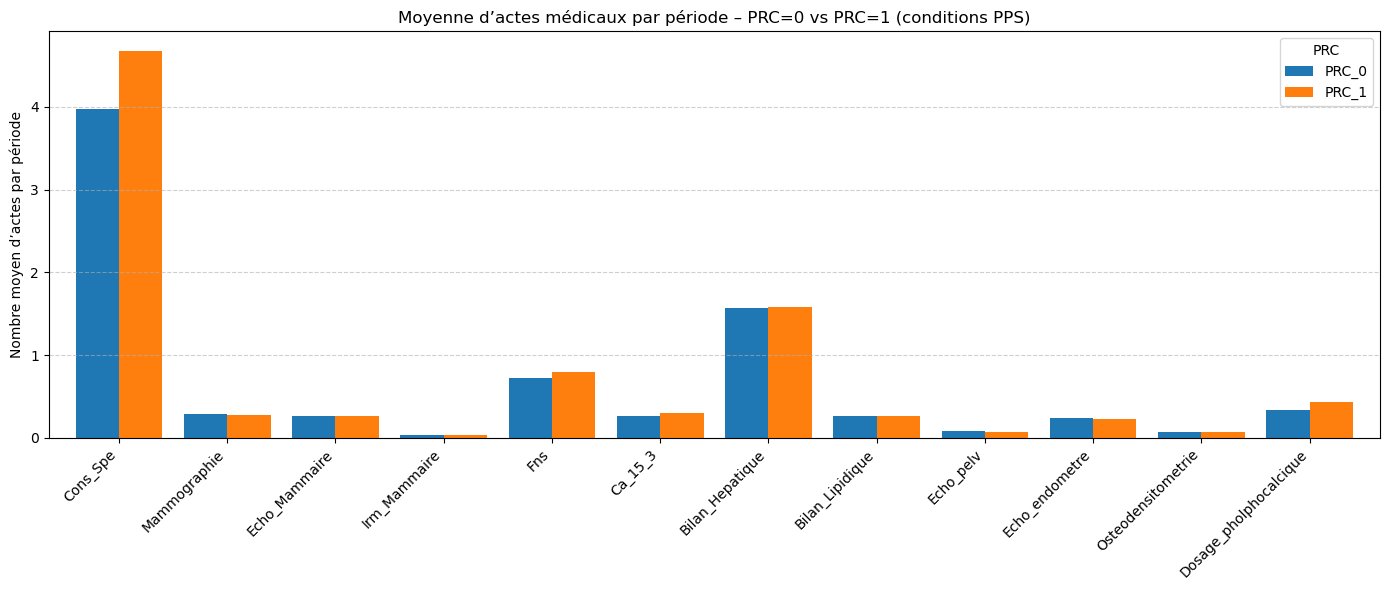

In [52]:
df_conformite = df_resumé_par_periode.copy()

def moyenne_par_acte_conditionnelle(df, acte, condition_col=None):
    if condition_col:
        df_filtré = df[df[condition_col] == 1]
    else:
        df_filtré = df
    if df_filtré.empty:
        return pd.DataFrame({f"PRC_0": [0], f"PRC_1": [0]}, index=[acte])
    moyennes = df_filtré.groupby("PRC")[[acte]].mean().T
    moyennes.columns = [f"PRC_{col}" for col in moyennes.columns]
    moyennes.index = [acte]
    return moyennes

actes_conditions = {
    "Cons_Spe": None,
    "Mammographie": None,
    "Echo_Mammaire": None,
    "Irm_Mammaire": None,
    "Fns": None,
    "Ca_15_3": None,
    "Bilan_Hepatique": None,
    "Bilan_Lipidique": None,
    "Echo_pelv": "Tamoxifen",                      # ↔ tamoxifène
    "Echo_endometre": "Tamoxifen",                 # ↔ tamoxifène
    "Osteodensitometrie": "Anti_arom",             # ↔ anti-aromatase
    "Dosage_pholphocalcique": "Anti_arom",         # ↔ anti-aromatase
    
}

moyennes_finales = []

for acte, condition in actes_conditions.items():
    moy = moyenne_par_acte_conditionnelle(df_conformite, acte, condition)
    moyennes_finales.append(moy)

df_moyennes_pps = pd.concat(moyennes_finales)

ax = df_moyennes_pps.plot(kind='bar', figsize=(14, 6), width=0.8)
plt.title("Moyenne d’actes médicaux par période – PRC=0 vs PRC=1 (conditions PPS)")
plt.ylabel("Nombre moyen d’actes par période")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title="PRC")
plt.tight_layout()
plt.show()


In [53]:
# Étape 2 : Colonnes de conformité PPS à générer
conf_cols = [
    "conf_Cons_Spe",
    "conf_Mammographie",
    "conf_Echo_Mammaire",
    "conf_Ca_15_3",
    "conf_Fns",
    "conf_Bilan_Hepatique",
    "conf_Bilan_Lipidique",
    "conf_Echo_pelv",
    "conf_Echo_endometre",
    "conf_Osteodensitometrie",
    "conf_Dosage_pholphocalcique"
]

results = []

patients = df_resumé_par_periode["ID_PATIENT"].unique()

for patient_id in patients:
    df_patient = df_resumé_par_periode[df_resumé_par_periode["ID_PATIENT"] == patient_id]
    row = {"ID_PATIENT": patient_id}

    # Init
    for col in conf_cols:
        row[col] = 0

    # Traitements
    tmx = df_patient["Tamoxifen"].iloc[0]
    arom = df_patient["Anti_arom"].iloc[0]
    ct = df_patient["CT"].iloc[0]

    # === Règles PPS ===

    # Consultation : tous les 3–6 mois → ~2/an → 10 consultations sur 5 ans
    row["conf_Cons_Spe"] = int(df_patient["Cons_Spe"].fillna(0).sum() >= 10)

    # Mammographie : à 12 mois (>= 1 fois à M12)
    row["conf_Mammographie"] = conforme_a_n_mois(df_patient, "Mammographie", 12)

    # Echo mammaire : possible → au moins 1 fois
    row["conf_Echo_Mammaire"] = int(df_patient["Echo_Mammaire"].fillna(0).sum() >= 1)

    # Ca 15.3 et FNS : 1 fois/an pendant 5 ans
    row["conf_Ca_15_3"] = conforme_annuel(df_patient, "Ca_15_3", 5)
    row["conf_Fns"] = conforme_annuel(df_patient, "Fns", 5)

    # Hormonothérapie
    # Bilan hépatique et lipidique obligatoires pour toutes les patientes (révision PPS)
    row["conf_Bilan_Hepatique"] = conforme_annuel(df_patient, "Bilan_Hepatique", 5)
    row["conf_Bilan_Lipidique"] = conforme_annuel(df_patient, "Bilan_Lipidique", 5)

    if tmx == 1:
        row["conf_Echo_pelv"] = conforme_annuel(df_patient, "Echo_pelv", 5)
        row["conf_Echo_endometre"] = conforme_annuel(df_patient, "Echo_endometre", 5)
    if arom == 1:
        row["conf_Osteodensitometrie"] = int(
            conforme_a_n_mois(df_patient, "Osteodensitometrie", 12) and
            conforme_a_n_mois(df_patient, "Osteodensitometrie", 24)
        )
        row["conf_Dosage_pholphocalcique"] = int(
            conforme_a_n_mois(df_patient, "Dosage_pholphocalcique", 12) and
            conforme_a_n_mois(df_patient, "Dosage_pholphocalcique", 24)
        )

    results.append(row)

# Étape 4 : Fusion avec le DataFrame principal
df_conformité = pd.DataFrame(results)
df_conformité[conf_cols] = df_conformité[conf_cols].astype(int)

# Nettoyage des anciennes colonnes
df_resumé_par_periode.drop(columns=[col for col in conf_cols if col in df_resumé_par_periode.columns], inplace=True)

# Fusion finale
df_resumé_par_periode = df_resumé_par_periode.merge(df_conformité, on="ID_PATIENT", how="left")


,ID_PATIENT,periode_suivi,PRC,Cons_Spe,Mammographie,Echo_Mammaire,Irm_Mammaire,Fns,Ca_15_3,Bilan_Hepatique,...,CT,mois_suivi,conf_Echo_pelv_y,conf_Echo_endometre_y,conf_Osteodensitometrie_y,conf_Dosage_pholphocalcique_y,conf_Echo_pelv,conf_Echo_endometre,conf_Osteodensitometrie,conf_Dosage_pholphocalcique
0,1101100325,M0–M3,0,11,1,1,1,1,0,4,...,1,1,0,0,0,0,0,0,0,0
1,1101100325,M12–M15,0,0,0,0,0,0,0,0,...,1,13,0,0,0,0,0,0,0,0
2,1101100325,M15–M18,0,0,0,0,0,0,0,0,...,1,16,0,0,0,0,0,0,0,0
3,1101100325,M18–M21,0,0,0,0,0,0,0,0,...,1,19,0,0,0,0,0,0,0,0
4,1101100325,M21–M24,0,0,0,0,0,0,0,0,...,1,22,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18186,4309400482,M54–M57,0,0,0,0,0,0,0,0,...,0,55,0,0,0,0,0,0,0,0
18187,4309400482,M57–M60,0,0,0,0,0,0,0,0,...,0,58,0,0,0,0,0,0,0,0
18188,4309400482,M60+,0,0,1,1,0,0,0,0,...,0,60,0,0,0,0,0,0,0,0
18189,4309400482,M6–M9,0,0,0,0,0,1,1,0,...,0,7,0,0,0,0,0,0,0,0


In [55]:
df_conformité.head(10)

,ID_PATIENT,conf_Cons_Spe,conf_Mammographie,conf_Echo_Mammaire,conf_Ca_15_3,conf_Fns,conf_Bilan_Hepatique,conf_Bilan_Lipidique,conf_Echo_pelv,conf_Echo_endometre,conf_Osteodensitometrie,conf_Dosage_pholphocalcique
0,1101100325,1,1,1,0,0,0,0,0,0,0,0
1,1101100717,0,1,1,0,1,1,1,0,0,0,0
2,1101100766,1,0,1,0,0,0,0,0,0,0,0
3,1102100494,1,1,1,0,1,1,0,0,0,0,1
4,1102101103,1,0,1,1,1,1,0,0,0,0,0
5,1102101659,1,0,1,0,1,0,1,0,0,0,0
6,1102102186,1,0,1,0,0,0,0,0,0,0,0
7,1103100275,1,0,1,0,1,1,0,0,0,0,1
8,1103101510,1,1,1,0,1,1,0,0,0,0,0
9,1103102437,1,0,1,1,1,1,0,0,0,0,0


In [54]:
df_resumé_par_periode.columns.tolist()

['ID_PATIENT',
 'periode_suivi',
 'PRC',
 'Cons_Spe',
 'Mammographie',
 'Echo_Mammaire',
 'Irm_Mammaire',
 'Fns',
 'Ca_15_3',
 'Bilan_Hepatique',
 'Bilan_Lipidique',
 'Echo_pelv',
 'Echo_endometre',
 'Osteodensitometrie',
 'Dosage_pholphocalcique',
 'conf_Irm_Mammaire',
 'mois_suivi',
 'Tamoxifen',
 'Anti_arom',
 'CT',
 'conf_Cons_Spe',
 'conf_Mammographie',
 'conf_Echo_Mammaire',
 'conf_Ca_15_3',
 'conf_Fns',
 'conf_Bilan_Hepatique',
 'conf_Bilan_Lipidique',
 'conf_Echo_pelv',
 'conf_Echo_endometre',
 'conf_Osteodensitometrie',
 'conf_Dosage_pholphocalcique']

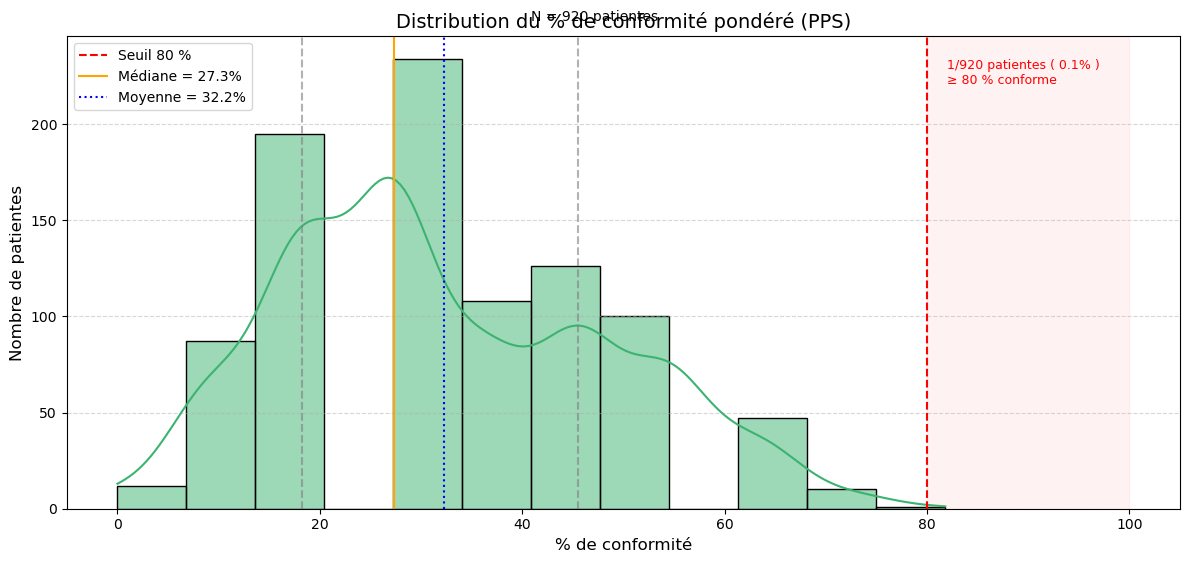

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Statistiques clés ---
serie = df_conformité["pct_PPS_pondéré"]
n      = len(serie)
mean   = serie.mean()
med    = serie.median()
q1, q3 = serie.quantile([.25, .75])
n_ok   = (serie >= 80).sum()

# --- Figure ---
plt.figure(figsize=(12, 6))

# Histogramme + KDE
sns.histplot(serie, bins=12, kde=True, color="mediumseagreen")

# Seuil 80 %
plt.axvline(80, ls="--", color="red",  label="Seuil 80 %")

# Médiane & moyenne
plt.axvline(med,  ls="-",  color="orange", label=f"Médiane = {med:.1f}%")
plt.axvline(mean, ls=":",  color="blue",   label=f"Moyenne = {mean:.1f}%")

# Quartiles
plt.axvline(q1, ls="--", color="grey", alpha=.6)
plt.axvline(q3, ls="--", color="grey", alpha=.6)

# Zone conforme ombrée
plt.axvspan(80, 100, color="red", alpha=.05)

# Texte résumé
plt.text(82, plt.ylim()[1]*.9,
         f"{n_ok}/{n} patientes ( {n_ok/n:.1%} )\n≥ 80 % conforme",
         color="red", fontsize=9)

# Habillage
plt.title("Distribution du % de conformité pondéré (PPS)", fontsize=14)
plt.xlabel("% de conformité", fontsize=12)
plt.ylabel("Nombre de patientes", fontsize=12)
plt.suptitle(f"N = {n} patientes", y=0.93, fontsize=10)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


distribution très déséquilibrée : la médiane (27 %) et la moyenne (32 %) révèlent qu’au moins la moitié des 920 patientes n’exécutent qu’un tiers ou moins des actes jugés prioritaires dans le PPS. La courbe est fortement « étirée » vers la droite : quelques patientes atteignent 50-65 % de conformité, mais ce sont des exceptions et une seule (0,1 %) franchit le seuil fixé à 80 %. Concrètement, la quasi-totalité de la cohorte laisse inachevée une large part du suivi recommandé ; l’écart entre la zone rouge (≥ 80 %) et le pic principal autour de 25-30 % souligne l’ampleur des manquements. Ces résultats invitent donc à identifier les obstacles (rappels insuffisants, difficultés d’accès, priorisation médicale différente) et à instaurer des actions ciblées pour rapprocher la population de ce niveau de conformité jugé acceptable.

In [65]:
df_resumé_par_periode.columns

Index(['ID_PATIENT', 'periode_suivi', 'PRC', 'Cons_Spe', 'Mammographie',
       'Echo_Mammaire', 'Irm_Mammaire', 'Fns', 'Ca_15_3', 'Bilan_Hepatique',
       'Bilan_Lipidique', 'Echo_pelv', 'Echo_endometre', 'Osteodensitometrie',
       'Dosage_pholphocalcique', 'conf_Irm_Mammaire', 'mois_suivi',
       'Tamoxifen', 'Anti_arom', 'CT', 'conf_Cons_Spe', 'conf_Mammographie',
       'conf_Echo_Mammaire', 'conf_Ca_15_3', 'conf_Fns',
       'conf_Bilan_Hepatique', 'conf_Bilan_Lipidique', 'conf_Echo_pelv',
       'conf_Echo_endometre', 'conf_Osteodensitometrie',
       'conf_Dosage_pholphocalcique'],
      dtype='object')

3769 périodes avec un score de 1 et 3131 périodes à score 0, soit aucun ou un seul acte réalisé pendant ces périodes , La majorité des patientes ne réalisent qu’un ou deux actes recommandés par période.


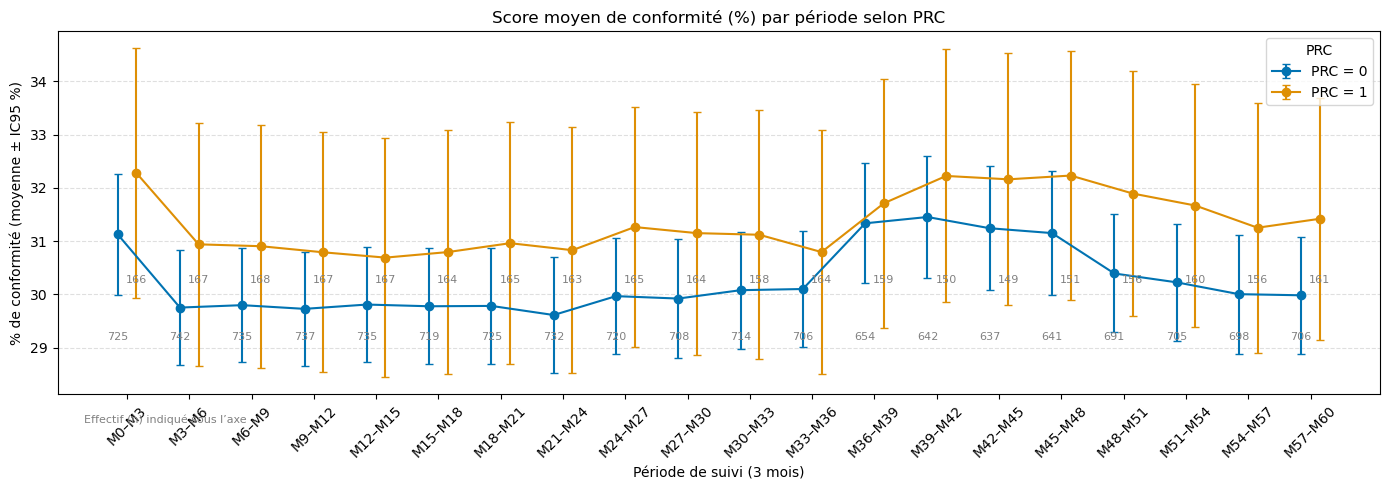

In [73]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats

# ------------------------------------------------------------
# 0) Nettoyage / recodage PRC  ➜ int 0 ou 1
# ------------------------------------------------------------
df = df_resumé_par_periode.copy()          # raccourci
df["PRC"] = (
    df["PRC"].astype(str)                 # tout en chaînes
            .str.strip()                  # supprime espaces
            .replace({"False": "0", "True": "1", "nan": np.nan})
            .astype(float)
            .fillna(0)                    # NaN -> 0 (à adapter si besoin)
            .astype(int)
)

# ------------------------------------------------------------
# 1) Score de conformité (pourcentage d’actes réalisés)
# ------------------------------------------------------------
conf_cols = [c for c in df.columns if c.startswith("conf_")]

df["score_pct"] = (
    100 * df[conf_cols].sum(axis=1) / len(conf_cols)
)

# ------------------------------------------------------------
# 2) Filtre période  • ordre chronologique
# ------------------------------------------------------------
df_plot = df.query("periode_suivi != 'M60+'").copy()

def debut_periode(lbl: str) -> int:
    """Retourne le début de l’intervalle en mois (ex. 'M0–3' → 0)."""
    return int(''.join(filter(str.isdigit, lbl.split('–')[0])))

ordre = sorted(df_plot["periode_suivi"].dropna().unique(), key=debut_periode)
df_plot["periode_suivi"] = pd.Categorical(df_plot["periode_suivi"],
                                          categories=ordre, ordered=True)

# ------------------------------------------------------------
# 3) Agrégation : moyenne, n, IC 95 %
# ------------------------------------------------------------
summary = (df_plot
           .groupby(["periode_suivi", "PRC"])["score_pct"]
           .agg(mean="mean",
                n="count",
                se=lambda x: stats.sem(x, nan_policy="omit"))
           .reset_index())

summary["ci"] = summary.apply(
    lambda r: r.se * stats.t.ppf(0.975, r.n-1) if r.n > 1 else 0,
    axis=1
)

# ------------------------------------------------------------
# 4) Tracé – courbes décalées pour qu’elles ne se superposent pas
# ------------------------------------------------------------
palette = sns.color_palette("colorblind", 2)
x = np.arange(len(ordre))           # positions centrales pour les périodes
offset = 0.15                       # décalage gauche / droite

fig, ax = plt.subplots(figsize=(14, 5))

for prc_val, ofs, col in [(0, -offset, palette[0]),
                          (1,  +offset, palette[1])]:
    grp = summary.query("PRC == @prc_val").set_index("periode_suivi").reindex(ordre)
    
    # ligne + marqueurs
    ax.errorbar(x + ofs, grp["mean"], yerr=grp["ci"],
                fmt="o-", capsize=3, label=f"PRC = {prc_val}", color=col)
    
    # effectifs sous l’axe x (une seule fois par période)
    for xi, n in zip(x, grp["n"]):
        ax.annotate(f"{int(n)}", (xi + ofs, grp["mean"].min()),
                    xytext=(0, -18), textcoords="offset points",
                    ha="center", fontsize=8, color="grey")

# ------------------------------------------------------------
# 5) Habillage final
# ------------------------------------------------------------
ax.set_xticks(x)
ax.set_xticklabels(ordre, rotation=45)
ax.set_xlabel("Période de suivi (3 mois)")
ax.set_ylabel("% de conformité (moyenne ± IC95 %)")
ax.set_title("Score moyen de conformité (%) par période selon PRC")
ax.grid(axis="y", linestyle="--", alpha=.4)
ax.legend(title="PRC", loc="upper right")
ax.annotate("Effectif (n) indiqué sous l’axe", xy=(0, 0),
            xycoords=('axes fraction', 'figure fraction'),
            xytext=(.02, -.08), textcoords='axes fraction',
            fontsize=8, color="grey")

plt.tight_layout()
plt.show()


Oui, les patientes incluses dans le programme PRC (PRC = 1) obtiennent en moyenne un score de conformité plus élevé que celles qui ne sont pas suivies par ce programme (PRC = 0), et ce à pratiquement chaque période de trois mois 

In [ ]:
df_score_patient = df_resumé_par_periode.groupby("ID_PATIENT")[colonnes_conf].max().reset_index()

df_score_patient["score_conformité"] = df_score_patient[colonnes_conf].sum(axis=1)


In [77]:
import pandas as pd, plotly.graph_objects as go
from itertools import chain

def sankey_from_df(df_links, title="Sankey"):
    """df_links : DataFrame(source, target, value)"""
    if df_links.empty:
        print("⚠️  Aucune donnée à afficher.")
        return
    labels = pd.Index(sorted(set(chain(df_links["source"], df_links["target"]))), name="label")
    codes  = {lab: i for i, lab in enumerate(labels)}
    df_links = df_links.replace(codes)

    fig = go.Figure(go.Sankey(
        arrangement="snap",
        node=dict(label=labels.tolist(), pad=15, thickness=15,
                  line=dict(color="black", width=0.5)),
        link=dict(source=df_links["source"], target=df_links["target"],
                  value=df_links["value"])
    ))
    fig.update_layout(title_text=title, font_size=11, height=550, width=960)
    fig.show()
    return fig


In [78]:
acts = [c for c in df.columns if c.startswith("conf_")]
# Choisir :   periode_unique = "M0–3"   ou   periode_unique = None (pour toutes)
periode_unique = None          # ← mets "M0–3" pour une seule période

sub = df.copy()
if periode_unique:
    sub = sub[sub["periode_suivi"] == periode_unique]

sub["score_band"] = pd.cut(sub["score_pct"],
                           bins=[0,20,40,60,80,100],
                           labels=["0-20 %","20-40 %","40-60 %","60-80 %","80-100 %"],
                           right=False)

linksA = (sub
          .melt(id_vars=["periode_suivi","score_band"], value_vars=acts,
                var_name="acte", value_name="fait")
          .query("fait == 1")
          .groupby(["periode_suivi","acte","score_band"])
          .size().reset_index(name="value"))

if periode_unique:
    linksA = linksA.drop(columns="periode_suivi")        # un seul graphique
    sankey_from_df(linksA.rename(columns={"acte":"source","score_band":"target"}),
                   title=f"Actes ➜ score {periode_unique}")
else:
    # un Sankey par période
    for per, dper in linksA.groupby("periode_suivi"):
        sankey_from_df(dper.rename(columns={"acte":"source","score_band":"target"}),
                       title=f"Actes ➜ score {per}")


In [80]:
family_map = {
    "conf_Mammographie":"Imagerie","conf_Echo_Mammaire":"Imagerie","conf_Irm_Mammaire":"Imagerie",
    "conf_Cons_Spe":"Consultation",
    "conf_Fns":"Biologie","conf_Ca_15_3":"Biologie","conf_Bilan_Hepatique":"Biologie","conf_Bilan_Lipidique":"Biologie",
    "conf_Echo_pelv":"Gynécologie","conf_Echo_endometre":"Gynécologie",
    "conf_Osteodensitometrie":"Ostéo","conf_Dosage_pholphocalcique":"Ostéo"
}

df_long = (df.melt(id_vars=["periode_suivi"], value_vars=list(family_map),
                   var_name="acte", value_name="fait")
             .query("fait == 1"))
df_long["famille"] = df_long["acte"].map(family_map)

linksC = (df_long.groupby(["periode_suivi","famille"])
          .size().reset_index(name="value")
          .rename(columns={"periode_suivi":"source","famille":"target"}))

sankey_from_df(linksC, title="Mix d’actes par période")


In [85]:
import re, pandas as pd, numpy as np, plotly.graph_objects as go
from itertools import chain

# ──────────────────────────────────────────────────────────────────────────
# 0) Fonction Sankey
# ──────────────────────────────────────────────────────────────────────────
def sankey_from_df(df_links, title):
    if df_links.empty:
        print(f"⚠️  Aucune donnée pour {title}")
        return
    labels = pd.Index(sorted(set(chain(df_links["source"], df_links["target"]))), name="label")
    codes  = {lab: i for i, lab in enumerate(labels)}
    df_num = df_links.replace({"source": codes, "target": codes})

    fig = go.Figure(go.Sankey(
        arrangement="snap",
        node=dict(label=labels.tolist(), pad=15, thickness=15,
                  line=dict(color="black", width=0.5)),
        link=dict(source=df_num["source"], target=df_num["target"], value=df_num["value"])
    ))
    fig.update_layout(title_text=title, font_size=11, height=550, width=940)
    fig.show()

# ──────────────────────────────────────────────────────────────────────────
# 1) Lister les périodes dans l’ordre chrono : M0–M3, M3–M6, …
# ──────────────────────────────────────────────────────────────────────────
def start_month(label):
    """'M0–M3' → 0  |  'M57–M60' → 57 |  'M60+' → 60  (met 99 si 'M60+')"""
    if label == "M60+":
        return 60
    m = re.match(r"M(\d+)–M?(\d+)", label)
    return int(m.group(1)) if m else 99

periodes = sorted(df["periode_suivi"].unique(), key=start_month)

# ──────────────────────────────────────────────────────────────────────────
# 2) Catégoriser la conformité (Basse < 20 %, Moy 20-60 %, Haute ≥ 60 %)
# ──────────────────────────────────────────────────────────────────────────
bins_pct  = [0, 20, 60, 100]
labels_cat = ["Basse", "Moyenne", "Haute"]
df["conf_cat"] = pd.cut(df["score_pct"], bins=bins_pct, labels=labels_cat, right=False)

# ──────────────────────────────────────────────────────────────────────────
# 3) Boucle : chaque paire consécutive → Sankey
# ──────────────────────────────────────────────────────────────────────────
for p_cur, p_next in zip(periodes[:-1], periodes[1:]):
    # (a) sélection des patientes ayant les DEUX périodes
    sub_cur  = df.query("periode_suivi == @p_cur")[["ID_PATIENT", "PRC", "conf_cat"]]
    sub_next = df.query("periode_suivi == @p_next")[["ID_PATIENT", "conf_cat"]]
    wide = (sub_cur
            .merge(sub_next, on="ID_PATIENT", suffixes=("_t", "_t1"))
            .rename(columns={"conf_cat_t":"conf_t", "conf_cat_t1":"conf_t1"}))

    if wide.empty:            # personne n'a les deux fenêtres
        continue

    # (b) liens PRC ➜ conf_t ➜ conf_t1
    links = (wide.groupby(["PRC","conf_t","conf_t1"])
                  .size().reset_index(name="value"))

    links["source"] = links["PRC"].map({0:"PRC 0", 1:"PRC 1"}) + " ➜ " + links["conf_t"].astype(str)
    links["target"] = links["conf_t"].astype(str) + " ➜ " + links["conf_t1"].astype(str)
    links = links[["source", "target", "value"]]

    title = f"Flux PRC ➜ conformité {p_cur} ➜ {p_next}  (n = {len(wide)})"
    sankey_from_df(links, title)


Passage Basse → Moyenne = amélioration du suivi : la patiente a ajouté plusieurs actes entre deux périodes.

Le fait que ça arrive quand PRC = 0 indique une amélioration sans l’appui du programme — mais c’est rare.

## En gros pour cette partie 

#### Le graphe orange montre que chaque trimestre est rarement complet (score 0 à 2 dominant),

#### Le graphe bleu montre que malgré cela, certaines patientes parviennent à cumulativement respecter 4 à 6 critères sur 5 ans, ce qui est logique.

## Traitement d'Excès d'actes médicaux 

In [ ]:
seuils_3mois = {
    "Cons_Med_Gen": 1,
    "Cons_Spe": 1,
    "Mammographie": 0.25,
    "Ca_15_3": 0.25,
    "Fns": 0.25,
    "Bilan_Hepatique": 0.25,
    "Bilan_Lipidique": 0.25,
    "Echo_pelv": 0.25  # Conditionnel
}


In [ ]:
for acte, seuil in seuils_3mois.items():
    col_name = f"excès_{acte}"
    if acte == "Echo_pelv":
        # Cas conditionnel : uniquement si Tamoxifen == 1
        df_resumé_par_periode[col_name] = df_resumé_par_periode.apply(
            lambda row: 1 if row["Tamoxifen"] == 1 and row.get(acte, 0) > seuil else 0, axis=1
        )
    elif acte in df_resumé_par_periode.columns:
        df_resumé_par_periode[col_name] = (df_resumé_par_periode[acte] > seuil).astype(int)
    else:
        df_resumé_par_periode[col_name] = 0  # si l'acte est absent


In [ ]:
colonnes_excès = [f"excès_{acte}" for acte in seuils_3mois.keys()]
df_resumé_par_periode["score_excès"] = df_resumé_par_periode[colonnes_excès].sum(axis=1)


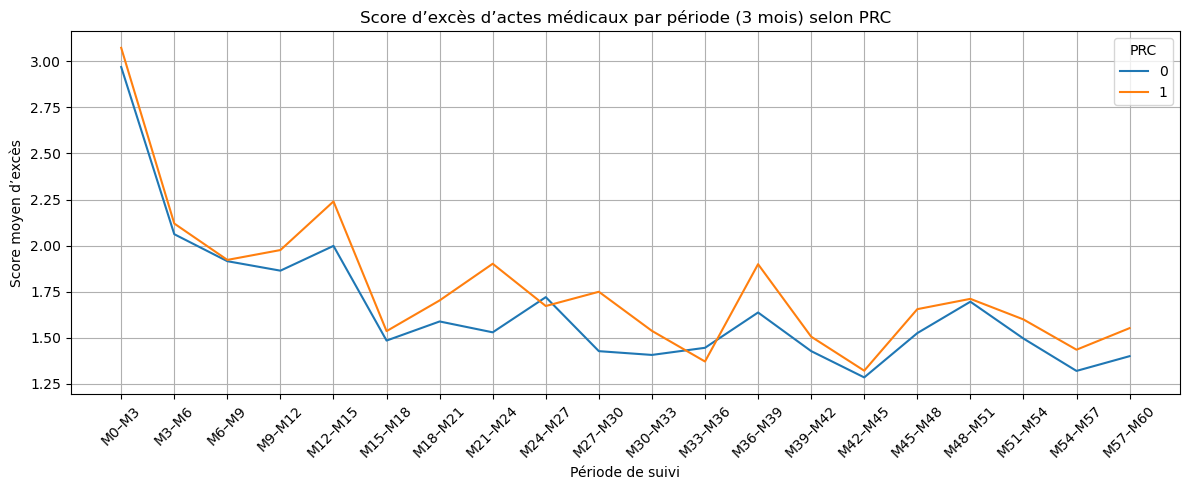

In [ ]:
périodes_valides = [x for x in df_resumé_par_periode["periode_suivi"].dropna().unique() if "60+" not in x]

ordre = sorted(périodes_valides, key=lambda x: int(x[1:].split("–")[0]))

if "M60+" in df_resumé_par_periode["periode_suivi"].values:
    ordre.append("M60+")

df_resumé_par_periode["periode_suivi"] = pd.Categorical(df_resumé_par_periode["periode_suivi"], categories=ordre, ordered=True)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=df_resumé_par_periode[df_resumé_par_periode["periode_suivi"] != "M60+"],
    x="periode_suivi",
    y="score_excès",
    hue="PRC",
    estimator="mean",
    ci=None
)
plt.title("Score d’excès d’actes médicaux par période (3 mois) selon PRC")
plt.xlabel("Période de suivi")
plt.ylabel("Score moyen d’excès")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
from scipy.stats import shapiro

groupe_0 = df_resumé_par_periode[df_resumé_par_periode["PRC"] == 0]["score_excès"]
groupe_1 = df_resumé_par_periode[df_resumé_par_periode["PRC"] == 1]["score_excès"]

# Tester la normalité
stat0, p0 = shapiro(groupe_0.sample(500, random_state=1))
stat1, p1 = shapiro(groupe_1.sample(500, random_state=1))

print(f"Shapiro PRC = 0: p = {p0:.4f}")
print(f"Shapiro PRC = 1: p = {p1:.4f}")


stat, p = mannwhitneyu(groupe_0, groupe_1, alternative='two-sided')
print(f"Mann-Whitney U Test : U = {stat}, p-value = {p:.4f}")



Shapiro PRC = 0: p = 0.0000
Shapiro PRC = 1: p = 0.0000
Mann-Whitney U Test : U = 24101651.5, p-value = 0.0003


In [ ]:
print("Médiane PRC = 0 :", groupe_0.median())
print("Médiane PRC = 1 :", groupe_1.median())


Médiane PRC = 0 : 1.0
Médiane PRC = 1 : 1.0


### Pourquoi le score d’excès ?

Le score d’excès synthétise le nombre d’actes réalisés au-delà des seuils recommandés par le protocole PPS. Il permet d’identifier une possible surmédicalisation. Nous l’avons utilisé pour évaluer si le statut PRC est associé à un suivi potentiellement plus intensif que recommandé.

### Choix du test

Le test de Shapiro-Wilk montre que `score_excès` ne suit pas une distribution normale. Par conséquent, nous utilisons le test de Mann-Whitney U pour Évaluer si l'une des deux distributions tend à produire des valeurs plus grandes que l'autre.



### Résultat

- U = 24,101,651.5
- p-value = 0.0003

Cela indique une différence statistiquement significative dans la distribution du score d’excès selon le PRC. Les patientes avec PRC ont tendance à avoir un suivi plus intensif.


Silhouette (k=4) : 0.435

Effectifs par cluster :
0    583
1    321
2     10
3      6
Name: cluster, dtype: int64 

Profil moyen (% actes réalisés) :


,conf_Irm_Mammaire,conf_Cons_Spe,conf_Mammographie,conf_Echo_Mammaire,conf_Ca_15_3,conf_Fns,conf_Bilan_Hepatique,conf_Bilan_Lipidique,conf_Echo_pelv,conf_Echo_endometre,conf_Osteodensitometrie,conf_Dosage_pholphocalcique
cluster,,,,,,,,,,,,
0,2.4,75.3,53.0,93.1,3.6,8.2,1.9,1.7,0.0,2.6,0.0,2.6
1,3.3,86.9,62.3,98.1,55.1,93.5,88.5,33.0,0.0,9.7,0.0,18.7
2,5.7,90.0,70.0,100.0,50.0,50.0,30.0,0.0,100.0,100.0,0.0,10.0
3,2.4,83.3,83.3,100.0,50.0,50.0,66.7,50.0,0.0,0.0,100.0,16.7


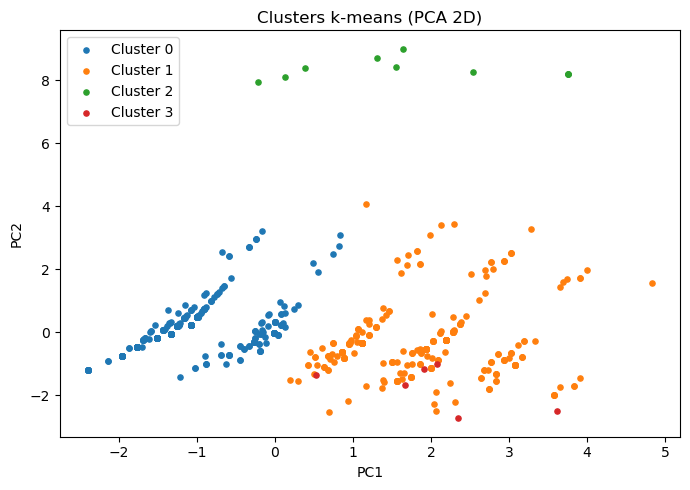

In [87]:
# ──────────────────────────────────────────────────────────────
# 0) Imports
# ──────────────────────────────────────────────────────────────
import pandas as pd, numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# ──────────────────────────────────────────────────────────────
# 1) Matrice % actes réalisés / patiente
# ──────────────────────────────────────────────────────────────
acts   = [c for c in df.columns if c.startswith("conf_")]   # colonnes 0/1
X_pct  = df.groupby("ID_PATIENT")[acts].mean() * 100        # 0-100 %

# ──────────────────────────────────────────────────────────────
# 2) Standardisation
# ──────────────────────────────────────────────────────────────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_pct)

# ──────────────────────────────────────────────────────────────
# 3) PCA : 5 axes pour le modèle, 2 axes pour le plot
# ──────────────────────────────────────────────────────────────
pca_5  = PCA(n_components=5, random_state=42)
X_pca5 = pca_5.fit_transform(X_scaled)

pca_2  = PCA(n_components=2, random_state=42)
X_pca2 = pca_2.fit_transform(X_scaled)

# ──────────────────────────────────────────────────────────────
# 4) k-means
# ──────────────────────────────────────────────────────────────
k = 4                         # ← change si besoin
kmeans  = KMeans(n_clusters=k, random_state=42, n_init=10)
labels  = kmeans.fit_predict(X_pca5)

print(f"Silhouette (k={k}) : {silhouette_score(X_pca5, labels):.3f}")

# ──────────────────────────────────────────────────────────────
# 5) Profil des clusters
# ──────────────────────────────────────────────────────────────
clusters = X_pct.copy()
clusters["cluster"] = labels

counts  = clusters["cluster"].value_counts().sort_index()
profile = clusters.groupby("cluster").mean().round(1)

print("\nEffectifs par cluster :")
print(counts, "\n")
print("Profil moyen (% actes réalisés) :")
display(profile)

# ──────────────────────────────────────────────────────────────
# 6) Visualisation 2D (PC1-PC2)
# ──────────────────────────────────────────────────────────────
plt.figure(figsize=(7,5))
palette = sns.color_palette("tab10", k)
for c in range(k):
    plt.scatter(X_pca2[labels==c,0], X_pca2[labels==c,1],
                s=14, color=palette[c], label=f"Cluster {c}")
plt.title("Clusters k-means (PCA 2D)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()


| Cluster (effectif) | Profil dominant                                                                                       | Lecture clinique rapide                                                                                                                                                   |
| ------------------ | ----------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **0 (583)**        | **Consult 75 %** · Mammo 53 % · **Écho mammaire 93 %**<br>Biologie < 10 % · Gynéco/Ostéo \~ 0 %       | **Suivi “noyau dur” seulement**. Les patientes font l’imagerie mammaire et voient le spécialiste, mais négligent systématiquement les bilans sanguins et actes adjuvants. |
| **1 (321)**        | **Consult 87 %** · **Écho 98 %** · Mammo 62 %<br>Biologie **55-94 %** · Lipides 33 % · Endomètre 10 % | **Suivi large mais inégal**. Presque tout le cœur du PPS est fait ; il manque surtout les examens secondaires (lipides, écho pelvienne).                                  |
| **2 (10)**         | **Consult 90 %** · **Écho 100 %** · Mammo 70 %<br>Écho pelv 100 % · Endomètre 100 %                   | **Ultra-conforme “Gynéco complet”**. Petit groupe, probablement patientes sous tamoxifène suivies par gynécologue dédié.                                                  |
| **3 (6)**          | **Mammo 83 %** · **Écho 100 %** · Osteodensito 100 %<br>Biologie 50-66 %                              | **Spécifique “Ostéo”**. Suivi anti-aromatase : ostéodensito systématique mais peu d’examens gynéco.                                                                       |


| Élément affiché | Ce que c’est                                                                                                 | Comment on l’obtient                                |
| --------------- | ------------------------------------------------------------------------------------------------------------ | --------------------------------------------------- |
| **PC1 (axe x)** | Combinaison linéaire de **tous** les actes `conf_*` qui explique la plus grande part de variance (≈ 40-50 %) | 1ʳᵉ colonne de la matrice des composantes de la PCA |
| **PC2 (axe y)** | Seconde combinaison, orthogonale à PC1, 2ᵉ plus forte variance (≈ 15-25 %)                                   | 2ᵉ colonne de la même matrice                       |
